# 01 Model Inspection

Dieses Notebook untersucht `EleutherAI/pythia-410m` mit Fokus auf Sentiment-Analyse.  
Die eigentliche Logik liegt in separaten Python-Dateien; das Notebook ruft diese Funktionen nur in einer gut lesbaren Reihenfolge auf.


## 1. Installation & Imports

In diesem Kapitel werden die Projektmodule geladen, der Pfad für das Notebook gesetzt und das verfügbare Gerät ausgewählt.


In [290]:
%load_ext autoreload
%autoreload 2

import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

current_dir = Path.cwd()
if (current_dir / "assignement" / "utils" / "config.py").exists():
    utils_dir = current_dir / "assignement" / "utils"
elif (current_dir / "utils" / "config.py").exists():
    utils_dir = current_dir / "utils"
elif (current_dir / "config.py").exists():
    utils_dir = current_dir
else:
    raise FileNotFoundError("Could not find the assignment utils directory.")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

import config
import model_utils
import lexicon_utils
import plotting_utils
import sentiment_embeddings
import linear_probe
import sst2_analysis

for module in [
    config,
    model_utils,
    lexicon_utils,
    plotting_utils,
    sentiment_embeddings,
    linear_probe,
    sst2_analysis,
]:
    importlib.reload(module)

from model_utils import (
    analyze_parameters,
    load_model_and_tokenizer,
    print_architecture_overview,
    run_top_k_predictions,
    setup_environment,
)
from sentiment_embeddings import (
    run_positive_negative_comparison,
    run_token_embedding_visualization,
)
from linear_probe import run_logistic_regression_probe
from sst2_analysis import run_sst2_inspection

device = setup_environment()


def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"PNG image not found in output directory: {image_path}")
    display(Image(filename=str(image_path)))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

  Kapitel 1: Installation & Imports
PyTorch-Version : 2.12.0+cpu
Gerät           : cpu


### Ergebnisinterpretation

Die Ausgabe zeigt, welche PyTorch-Version verwendet wird und ob das Modell auf CPU oder GPU läuft.  
Falls `cuda` angezeigt wird, können Modellinferenz und Embedding-Analysen deutlich schneller laufen. Bei `cpu` funktionieren die Analysen genauso, dauern aber länger.


## 2. Modell und Tokenizer laden

Hier werden der Tokenizer und das Sprachmodell geladen. Das Modell wird in den Evaluationsmodus gesetzt, damit keine Trainingsoperationen ausgeführt werden.


In [291]:
model, tokenizer = load_model_and_tokenizer(device)



  Kapitel 2: Modell und Tokenizer laden


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_

## 3. Architekturübersicht

Dieses Kapitel zeigt zentrale Architekturwerte wie Hidden Size, Anzahl der Schichten, Attention-Köpfe und Vokabulargröße.


In [292]:
print_architecture_overview(model)



  Kapitel 3: Architekturübersicht

--- Architektur-Parameter ---
Modelltyp              : gpt_neox
Versteckte Größe       : 1024
Schichten              : 24
Attention-Köpfe        : 16
Kopfdimension          : 64
Vokabulargröße         : 50304
Max. Positionen        : 2048


### Ergebnisinterpretation

Das verwendete Modell basiert auf der GPT-NeoX-Architektur und gehört zur Klasse der Decoder-Only Transformer. Im Gegensatz zur ursprünglichen Transformer-Architektur von Vaswani et al. aus dem Paper Attention Is All You Need, die aus einem Encoder- und einem Decoder-Stack besteht, verwendet GPT-NeoX ausschließlich Decoder-Blöcke mit maskierter Self-Attention. Dadurch kann das Modell autoregressiv arbeiten und auf Basis aller vorherigen Tokens das nächste Token vorhersagen.

Das Modell besitzt eine Vokabulargröße von 50.304 Tokens, eine Hidden Size von 1024 Dimensionen, 24 Transformer-Schichten, 16 Attention-Köpfe und eine maximale Kontextlänge von 2048 Tokens. Jedes Eingabetoken wird zunächst in einen 1024-dimensionalen Embedding-Vektor projiziert. Die Embedding-Schicht bildet somit den Ausgangspunkt aller weiteren Berechnungen innerhalb des Modells.

Jede der 24 Transformer-Schichten enthält zwei Layer-Normalization-Operationen, die die Aktivierungen stabilisieren und eine effizientere Verarbeitung der Informationen ermöglichen. Der Attention-Mechanismus basiert auf Multi-Head Self-Attention mit 16 Köpfen. Für jeden Token werden Query-, Key- und Value-Repräsentationen erzeugt, wobei alle drei Projektionen gemeinsam berechnet werden. Die resultierende Dimension von 3072 entspricht der dreifachen Hidden Size und wird anschließend in die einzelnen Query-, Key- und Value-Vektoren aufgeteilt. Da die Hidden Size 1024 beträgt und 16 Attention-Köpfe verwendet werden, besitzt jeder Kopf eine Dimension von 64 Merkmalen. Nach der Berechnung der Attention-Ergebnisse werden diese wieder in den ursprünglichen 1024-dimensionalen Hidden-State-Raum projiziert.

Auf den Attention-Block folgt ein mehrschichtiges Feed-Forward-Netzwerk (MLP). Dabei wird die interne Repräsentation zunächst von 1024 auf 4096 Dimensionen erweitert. Diese Expansion erhöht die Modellkapazität und ermöglicht die Verarbeitung komplexerer Merkmalskombinationen. Zwischen den beiden linearen Projektionen wird die nichtlineare GELU-Aktivierungsfunktion eingesetzt, welche sich in modernen Transformer-Architekturen als Standard etabliert hat. Anschließend wird die Repräsentation wieder auf die ursprüngliche Hidden Size von 1024 Dimensionen reduziert.

Zur Kodierung von Positionsinformationen verwendet GPT-NeoX Rotary Positional Embeddings (RoPE). Im Gegensatz zu klassischen Positions-Embeddings werden Positionsinformationen nicht additiv zu den Token-Embeddings hinzugefügt, sondern direkt über Rotationen innerhalb der Query- und Key-Repräsentationen eingebracht. Dadurch können relative Positionen zwischen Tokens effizient berücksichtigt werden und die Generalisierung auf längere Sequenzen wird verbessert.

Nach der letzten Transformer-Schicht wird eine finale Layer-Normalisierung durchgeführt, bevor die Hidden States auf die Größe des Vokabulars projiziert werden. Das Ergebnis dieser Projektion sind 50.304 Logits, also ein Score für jedes mögliche Token des Vokabulars. Durch Anwendung der Softmax-Funktion werden diese Logits in Wahrscheinlichkeiten umgewandelt, aus denen anschließend das nächste vorhergesagte Token ausgewählt wird.



## 4. Parameter-Zählung

Hier wird gezählt, wie viele Parameter in Embedding, Unembedding, Attention und MLP liegen. Zusätzlich wird eine Grafik zur Parameterverteilung gespeichert.



  Kapitel 4: Parameter-Zählung
Total parameters: 405,334,016
Token Embedding Params:   51,511,296  (12.71%)
Token Unembedding Params: 51,511,296  (12.71%)

Embed_in  data_ptr:  2112486440960
Embed_out data_ptr:  2111546916864
Embedding and Unembedding weights are tied? False

First layer parameter breakdown:
  input_layernorm.weight                   1,024
  input_layernorm.bias                     1,024
  post_attention_layernorm.weight          1,024
  post_attention_layernorm.bias            1,024
  attention.query_key_value.weight         3,145,728
  attention.query_key_value.bias           3,072
  attention.dense.weight                   1,048,576
  attention.dense.bias                     1,024
  mlp.dense_h_to_4h.weight                 4,194,304
  mlp.dense_h_to_4h.bias                   4,096
  mlp.dense_4h_to_h.weight                 4,194,304
  mlp.dense_4h_to_h.bias                   1,024

Component                       Params    Share
------------------------------------

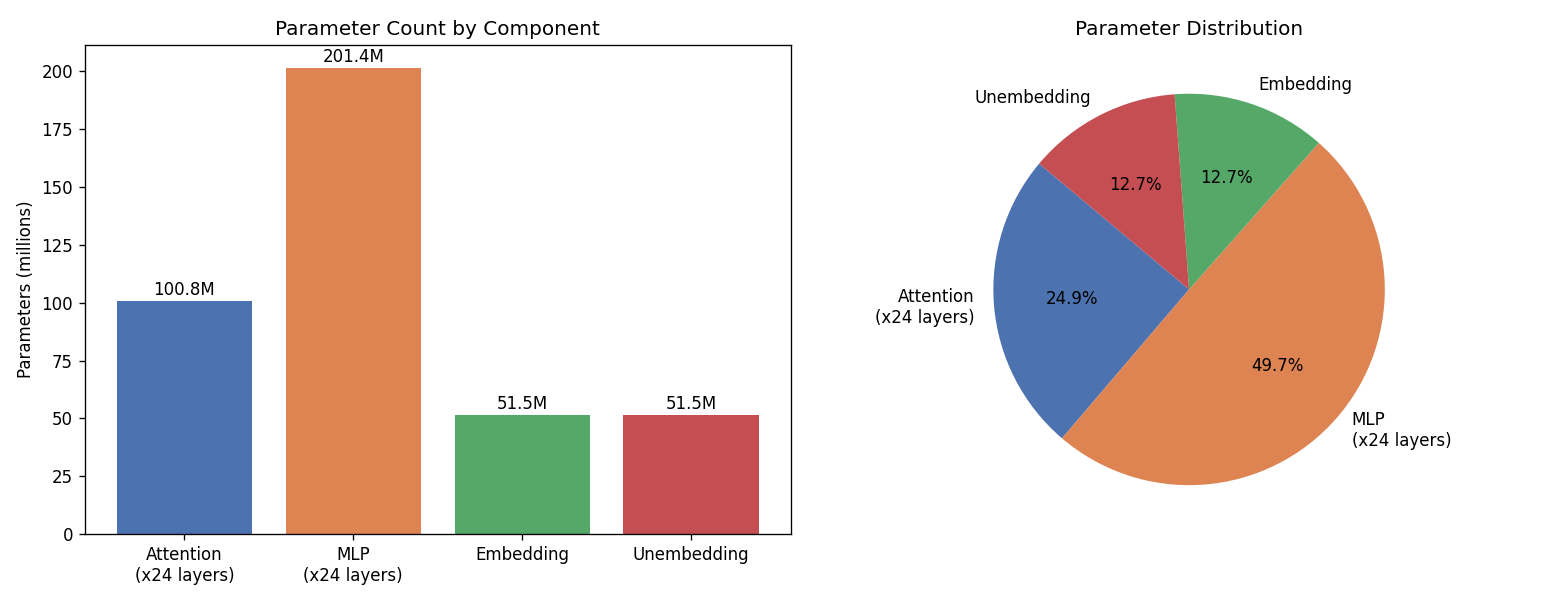

In [293]:
analyze_parameters(model)
display_image('parameterverteilung.png')

### Ergebnisinterpretation

Die Parameterzählung sind folgends verteilet:
- Embedding Matrix (50,304 × 1,024) = 51,511,296
- Transformer Layers (24 × 12,596,224) = 302,309,376
    - Transformer Layer (4,096 + 4,198,400 + 8,393,728) = 12,596,224
        - Input LayerNorm (1,024 + 1,024) = 2,048
        - Attention (3,148,800 + 1,049,600) = 4,198,400
            - QKV Projection ((1,024 × 3,072) + 3,072) = 3,148,800
            - Query/ Key Rotary Embedding = 0 (Pure Math)
            - Output Projection ((1,024 × 1,024) + 1,024) = 1,049,600
        - Post-Attention LayerNorm (1,024 + 1,024) = 2,048
    - MLP (4,198,400 + 4,195,328) = 8,393,728
        - Expansion ((1,024 × 4,096) + 4,096) = 4,198,400
        - Compression ((4,096 × 1,024) + 1,024) = 4,195,328
- Final LayerNorm (1,024 + 1,024) = 2,048
- Unembedding Matrix (1,024 × 50,304) = 51,511,296

Summe (51,511,296 + 302,309,376 + 2,048 + 51,511,296) = 405,334,016


Obwohl die Transformer-Architektur auf der bahnbrechenden Arbeit *Attention Is All You Need* von Vaswani et al. basiert, zeigt die Parameteranalyse dieses GPT-NeoX-Modells ein anderes Bild. Von insgesamt 12,6 Millionen Parametern pro Transformer-Layer entfallen lediglich etwa 4,2 Millionen (≈ 33 %) auf den Attention-Mechanismus, während rund 8,4 Millionen Parameter (≈ 67 %) im MLP-Block liegen. Betrachtet man die reine Parameterverteilung, könnte man daher scherzhaft sagen: **„Attention Is All You Need“ wird in der Praxis eher zu „Attention Is Only 25–33 % of What You Need“.** Der Großteil der Modellkapazität befindet sich nicht in der Attention selbst, sondern in den Feed-Forward-Netzwerken, die einen wesentlichen Beitrag zur Speicherung und Verarbeitung des im Modell enthaltenen Wissens leisten.


## 5. Top-K Vorhersagen

Für mehrere positive und negative Beispielprompts werden die wahrscheinlichsten nächsten Tokens ausgegeben. So sieht man, welche Fortsetzungen das Modell bevorzugt.


In [294]:
example_prompts = [
    "The food was delicious and the service was",
    "The food was disgusting and the service was",
    "I love this movie and I feel very",
    "I hate this movie and I feel very",
]

run_top_k_predictions(example_prompts, model, tokenizer, device)


  Kapitel 5: Top-K Vorhersagen

Prompt: The food was delicious and the service was
------------------------------------------------------------
1. Token: ' excellent'    | Token-ID:  7126 | Wahrscheinlichkeit: 0.1208
2. Token: ' very'         | Token-ID:  1077 | Wahrscheinlichkeit: 0.0802
3. Token: ' great'        | Token-ID:  1270 | Wahrscheinlichkeit: 0.0774
4. Token: ' impe'         | Token-ID: 19812 | Wahrscheinlichkeit: 0.0541
5. Token: ' good'         | Token-ID:  1175 | Wahrscheinlichkeit: 0.0498

Prompt: The food was disgusting and the service was
------------------------------------------------------------
1. Token: ' terrible'     | Token-ID: 11527 | Wahrscheinlichkeit: 0.0756
2. Token: ' awful'        | Token-ID: 18580 | Wahrscheinlichkeit: 0.0742
3. Token: ' poor'         | Token-ID:  4105 | Wahrscheinlichkeit: 0.0488
4. Token: ' horrible'     | Token-ID: 19201 | Wahrscheinlichkeit: 0.0483
5. Token: ' atroc'        | Token-ID: 36837 | Wahrscheinlichkeit: 0.0308

Prompt: I 

### Ergebnisinterpretation

Die Ergebnisse zeigen, dass das Modell in der Lage ist, den emotionalen Kontext eines Satzes zu erkennen und entsprechende Wortvorhersagen zu erzeugen. Bei positiv formulierten Eingaben wie "The food was delicious and the service was" dominieren positive Fortsetzungen wie excellent, great oder good. Im Gegensatz dazu erzeugt das Modell bei negativ formulierten Eingaben wie "The food was disgusting and the service was" überwiegend negative Fortsetzungen wie terrible, awful oder horrible.


## 6. Positiv vs. Negativ Vergleich

In diesem Kapitel wird das Hu-&-Liu-Opinion-Lexikon geladen. Danach werden nur Wörter behalten, die der Tokenizer als genau ein Token darstellt.  
Die Embeddings dieser Wörter werden mit PCA visualisiert; außerdem werden die gefilterten positiven und negativen Wörter als JSON gespeichert.


### Hu-&-Liu-Lexikon importieren

Für die Sentiment-Analyse wurde das Hu & Liu Sentiment Lexikon verwendet, eines der bekanntesten und am häufigsten eingesetzten lexikonbasierten Verfahren im Bereich Opinion Mining und Sentiment Analysis. Das Lexikon wurde von Minqing Hu und Bing Liu entwickelt und enthält englische Wörter, die manuell als positiv oder negativ klassifiziert wurden.

Das Lexikon besteht aus zwei Wortlisten: einer Liste positiver Begriffe und einer Liste negativer Begriffe. Die verwendete Version umfasst etwa 2.000 positive und etwa 4.800 negative Wörter. Beispiele für positive Begriffe sind good, excellent, amazing oder wonderful, während Wörter wie bad, terrible, awful oder horrible als negativ klassifiziert werden.

Bevor die Sentiment-Wörter gefiltert werden, wird geprüft, ob das Hu-&-Liu-Opinion-Lexikon lokal über NLTK verfügbar ist. Falls es noch nicht vorhanden ist, wird es in `assignement/inputs/nltk_data` heruntergeladen.

Nach dem Import werden die positiven und negativen Wörter aus dem Lexikon mit dem Tokenizer des Modells verbunden. Es bleiben nur Wörter übrig, die genau einem Token entsprechen. Anschließend werden deren Embeddings analysiert, als JSON gespeichert und in mehreren Grafiken dargestellt.


In [ ]:
# Check whether the Hu & Liu Opinion Lexicon is already available locally.
# If it is missing, download it into assignement/inputs/nltk_data.
# This step only prepares the raw positive and negative word lists.
lexicon_utils.import_hu_liu_dataset()

# Load the Hu & Liu positive and negative word lists.
# Keep only alphabetic words that Pythia represents as exactly one token.
# Extract their input embeddings, export the filtered JSON files,
# create the PCA plots, and return the data needed by later chapters.
sentiment_state = run_positive_negative_comparison(model, tokenizer)

### Ergebnisinterpretation

Hier wird sichtbar, wie viele Hu-&-Liu-Wörter nach dem Ein-Token-Filter übrig bleiben.  
Die PCA-Grafiken zeigen nicht perfekte Sentiment-Klassen, sondern räumliche Tendenzen im Embedding-Raum. Eine klare Trennung wäre ein starkes Signal; Überlappung bedeutet, dass Sentiment nicht nur durch zwei einfache Dimensionen beschrieben wird.


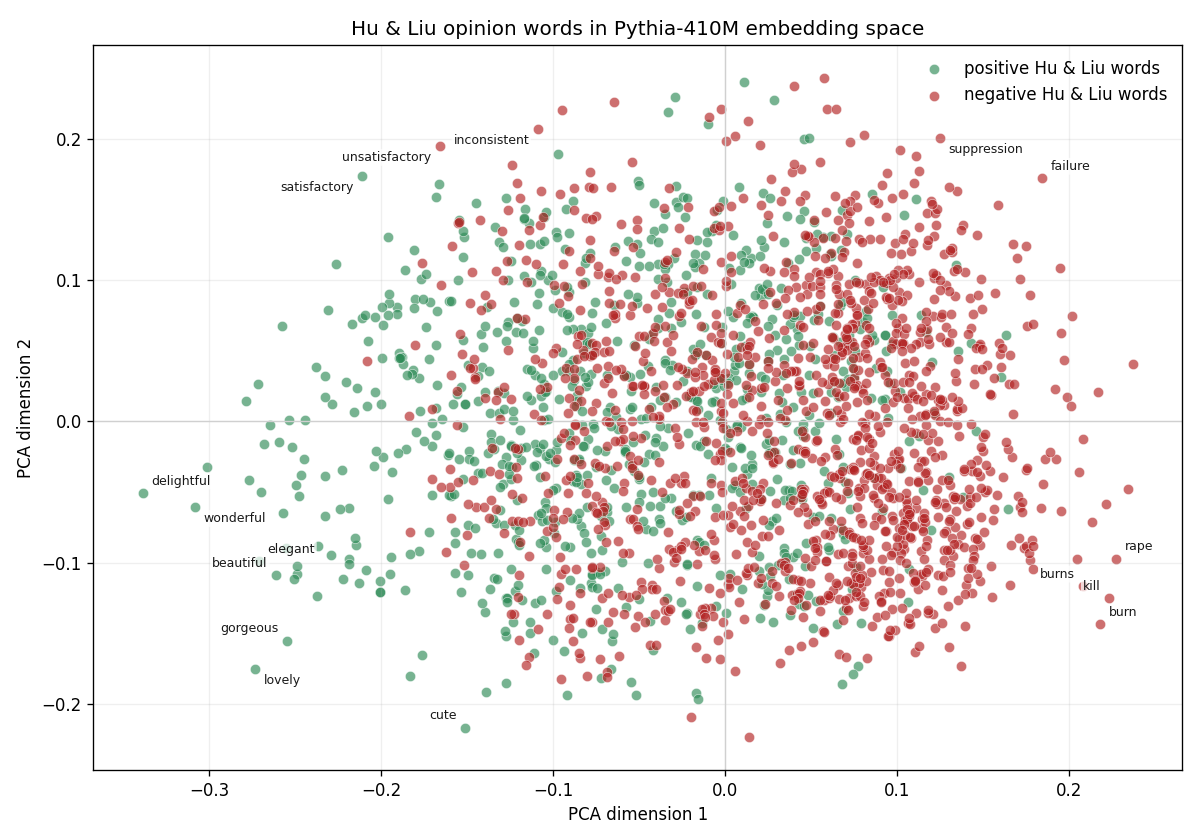

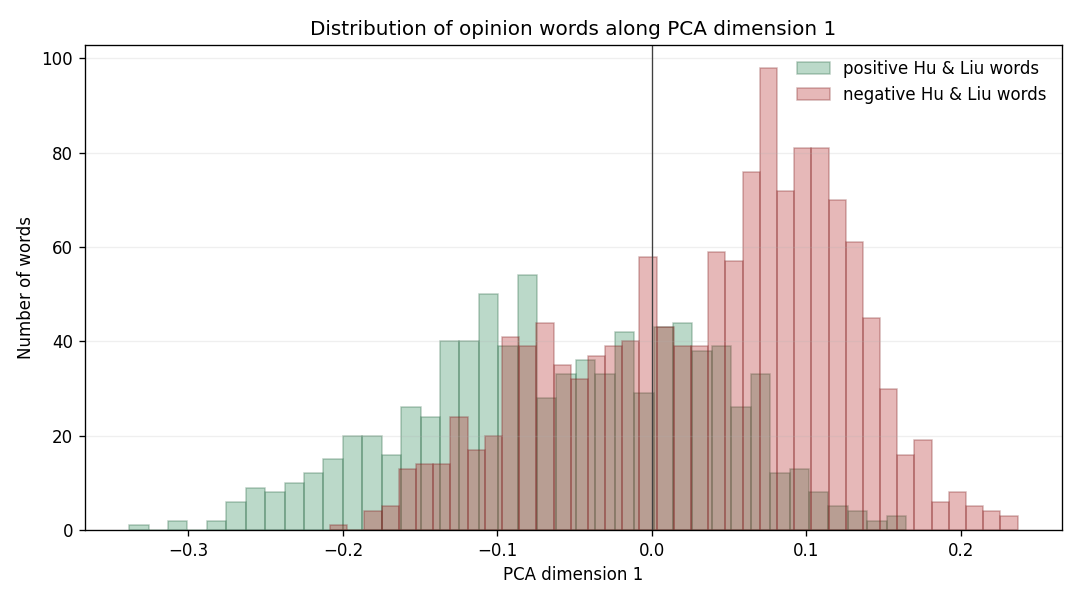

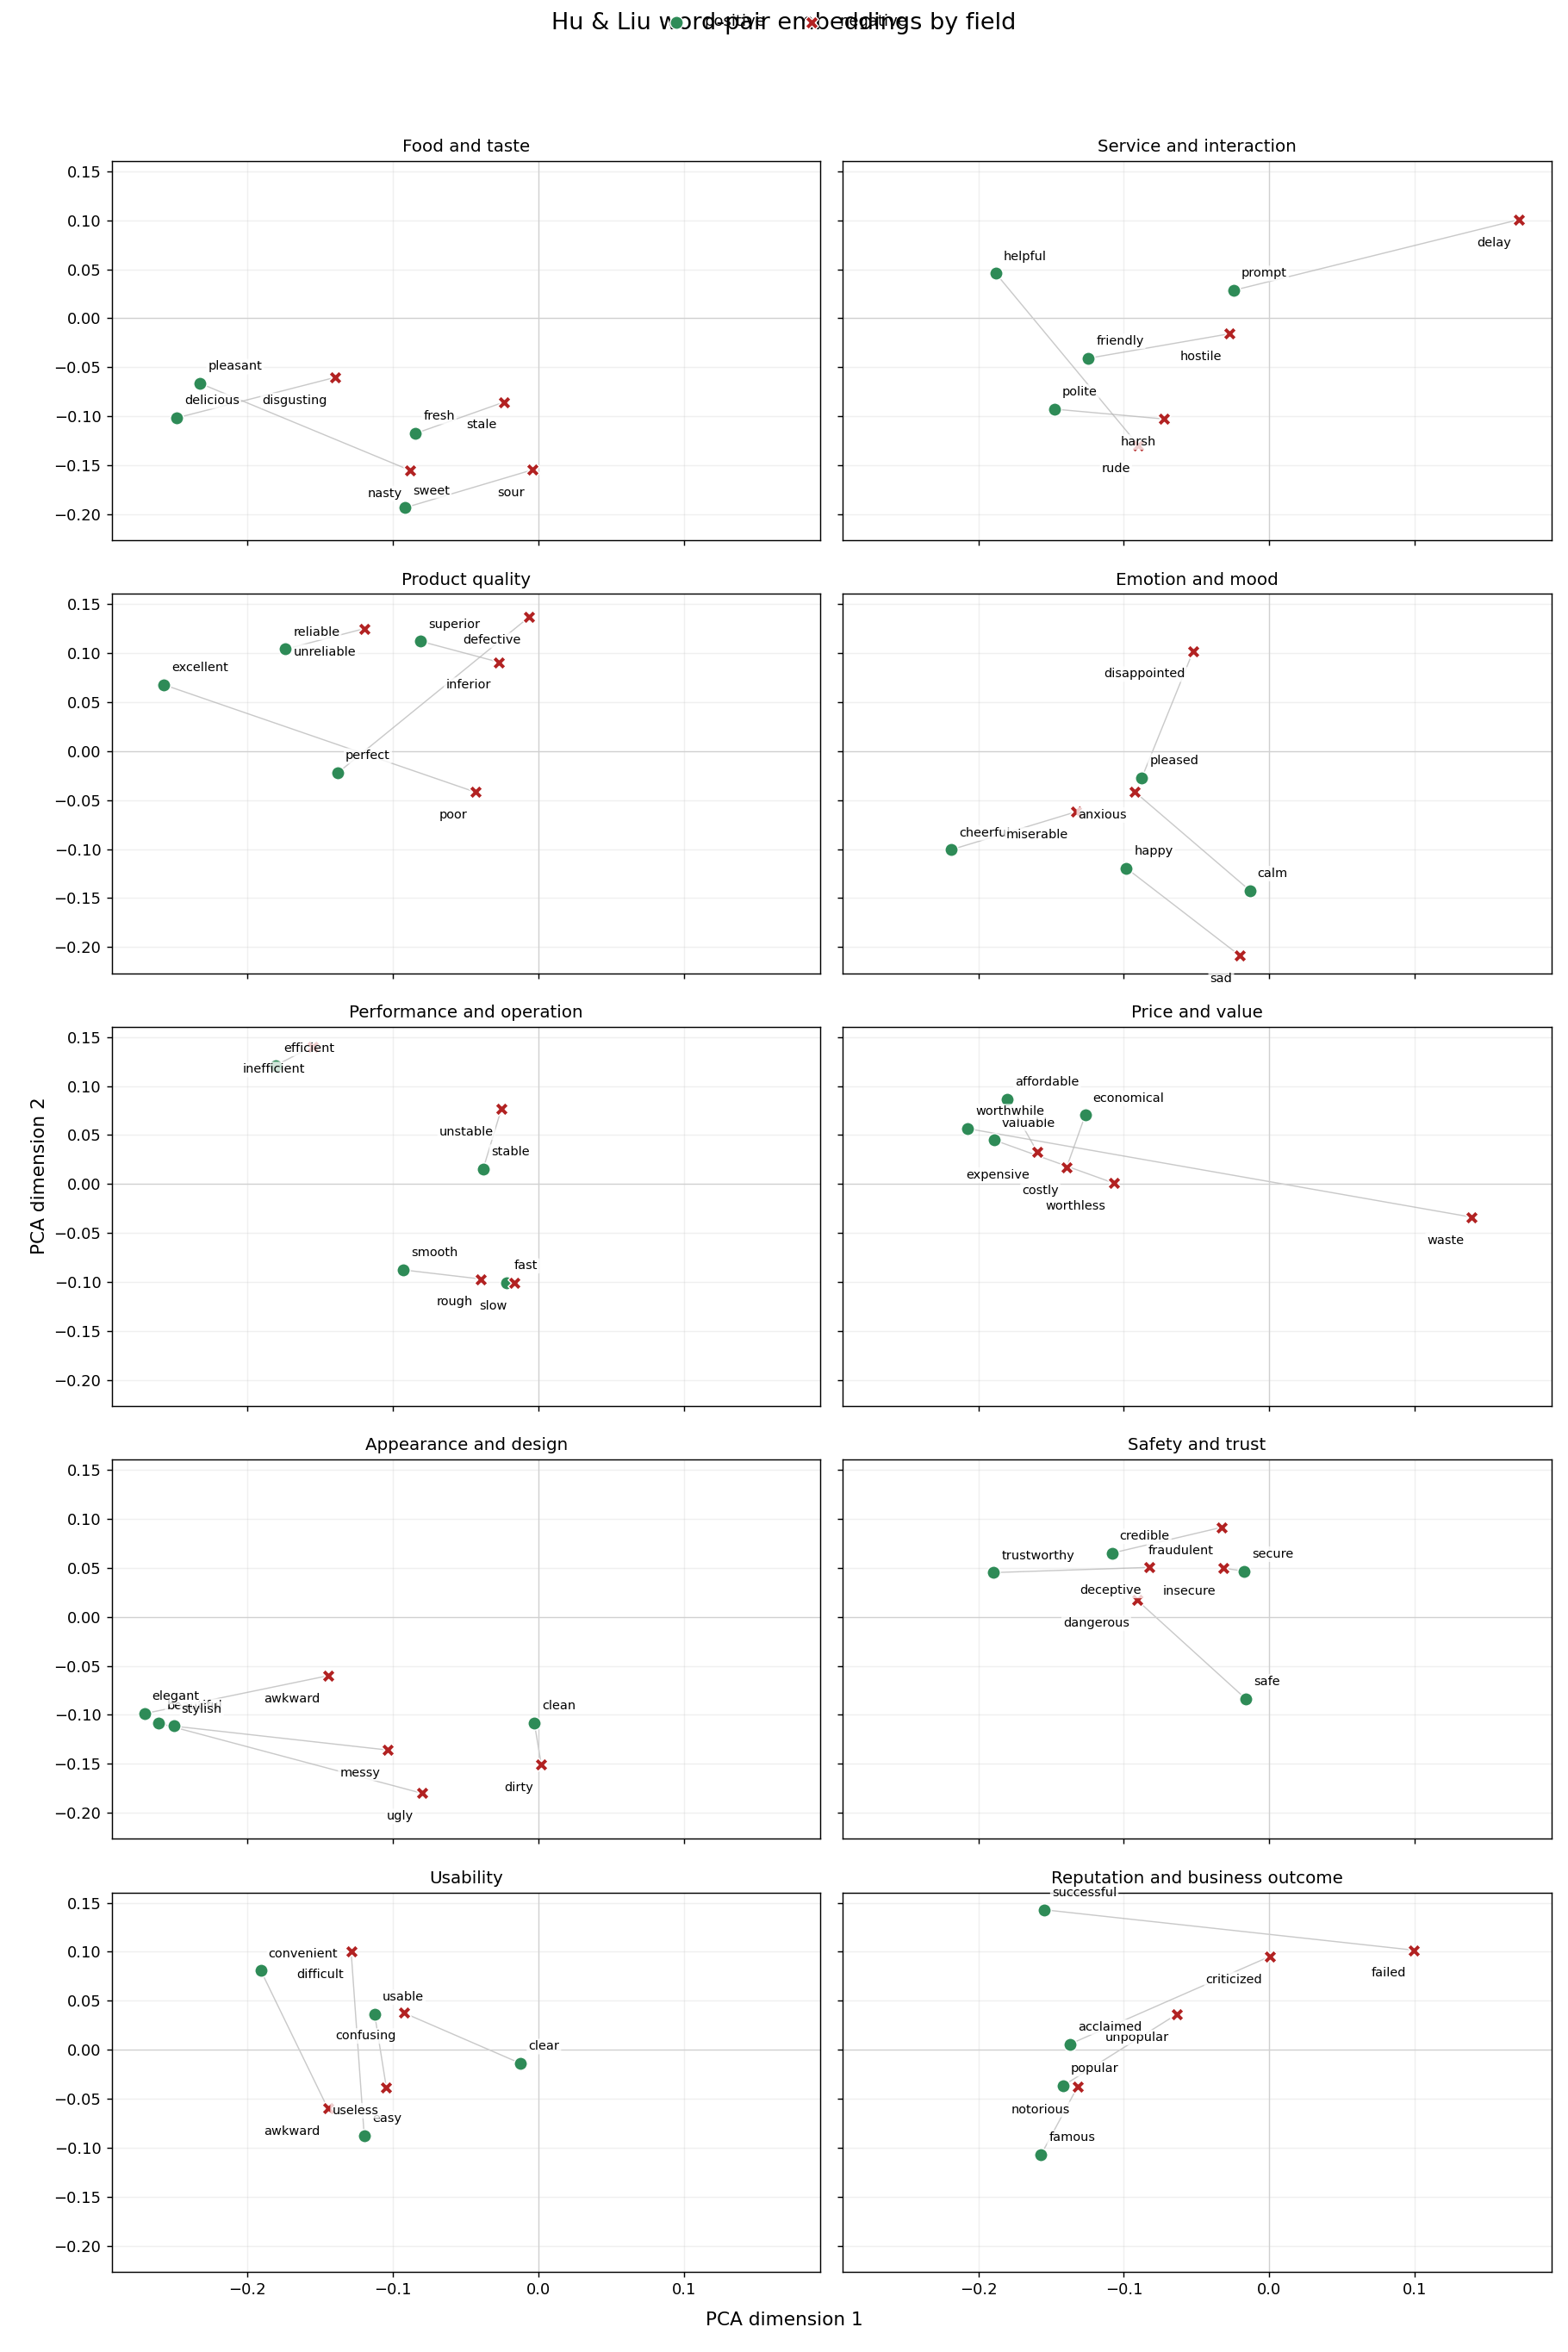

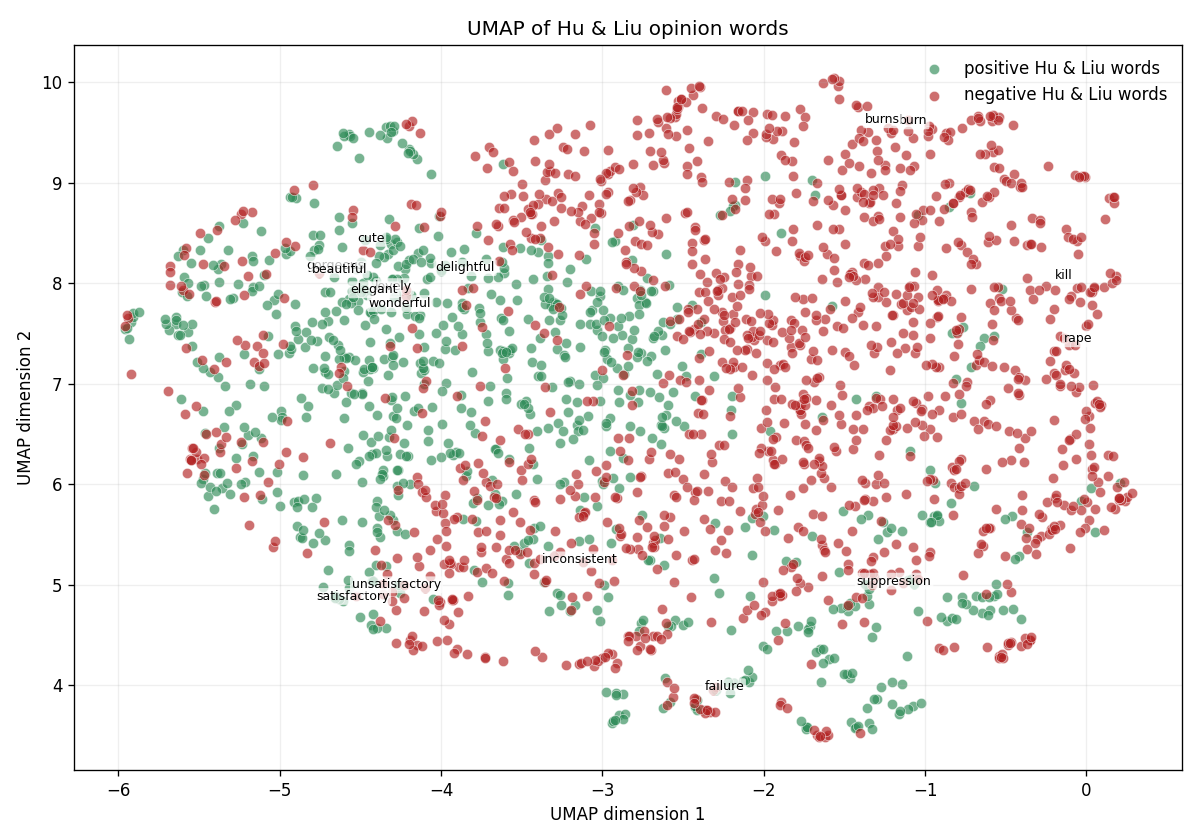

In [296]:
display_image('hu_liu_opinion_embeddings.png')
display_image('hu_liu_opinion_histogram.png')
display_image('hu_liu_field_embedding_panels.png')


### Interpretation der Grafiken

Die Scatterplots reduzieren hochdimensionale Embeddings auf zwei Dimensionen.  
Punkte, die nahe beieinander liegen, haben ähnliche Embedding-Vektoren. Die Farben zeigen, ob ein Wort im Hu-&-Liu-Lexikon positiv oder negativ gelabelt ist.  
Das Histogramm zeigt, ob positive und negative Wörter entlang der ersten PCA-Achse unterschiedlich verteilt sind.


## 7. Token-Embeddings visualisieren

Hier werden weitere Analysen auf den Sentiment-Token-Embeddings durchgeführt: L2-Normen, Cosine-Nachbarn, Embedding-Arithmetik und Projektionen auf eine Sentiment-Richtung.


### 7.1 Normen der Sentiment-Embeddings

Zuerst werden die L2-Normen der Sentiment-Token-Embeddings für alle Felder betrachtet.  
Jedes Feld wird in einer eigenen Box dargestellt, sodass positive und negative Wörter innerhalb desselben Themenbereichs verglichen werden können.


In [297]:
embedding_matrix = sentiment_state["embedding_matrix"]
positive_words = sentiment_state["positive_words"]
negative_words = sentiment_state["negative_words"]

sentiment_embeddings.run_embedding_norm_analysis(embedding_matrix)


Saved plot: sentiment_embedding_norms.png
Saved plot: sentiment_embedding_norms_by_field.png


### Ergebnisinterpretation

Die L2-Norm beschreibt die Länge eines Embedding-Vektors.  
Diese Länge ist nicht direkt gleichbedeutend mit Sentiment, kann aber zeigen, ob bestimmte Wörter im Embedding-Raum stärker oder schwächer ausgeprägt sind.


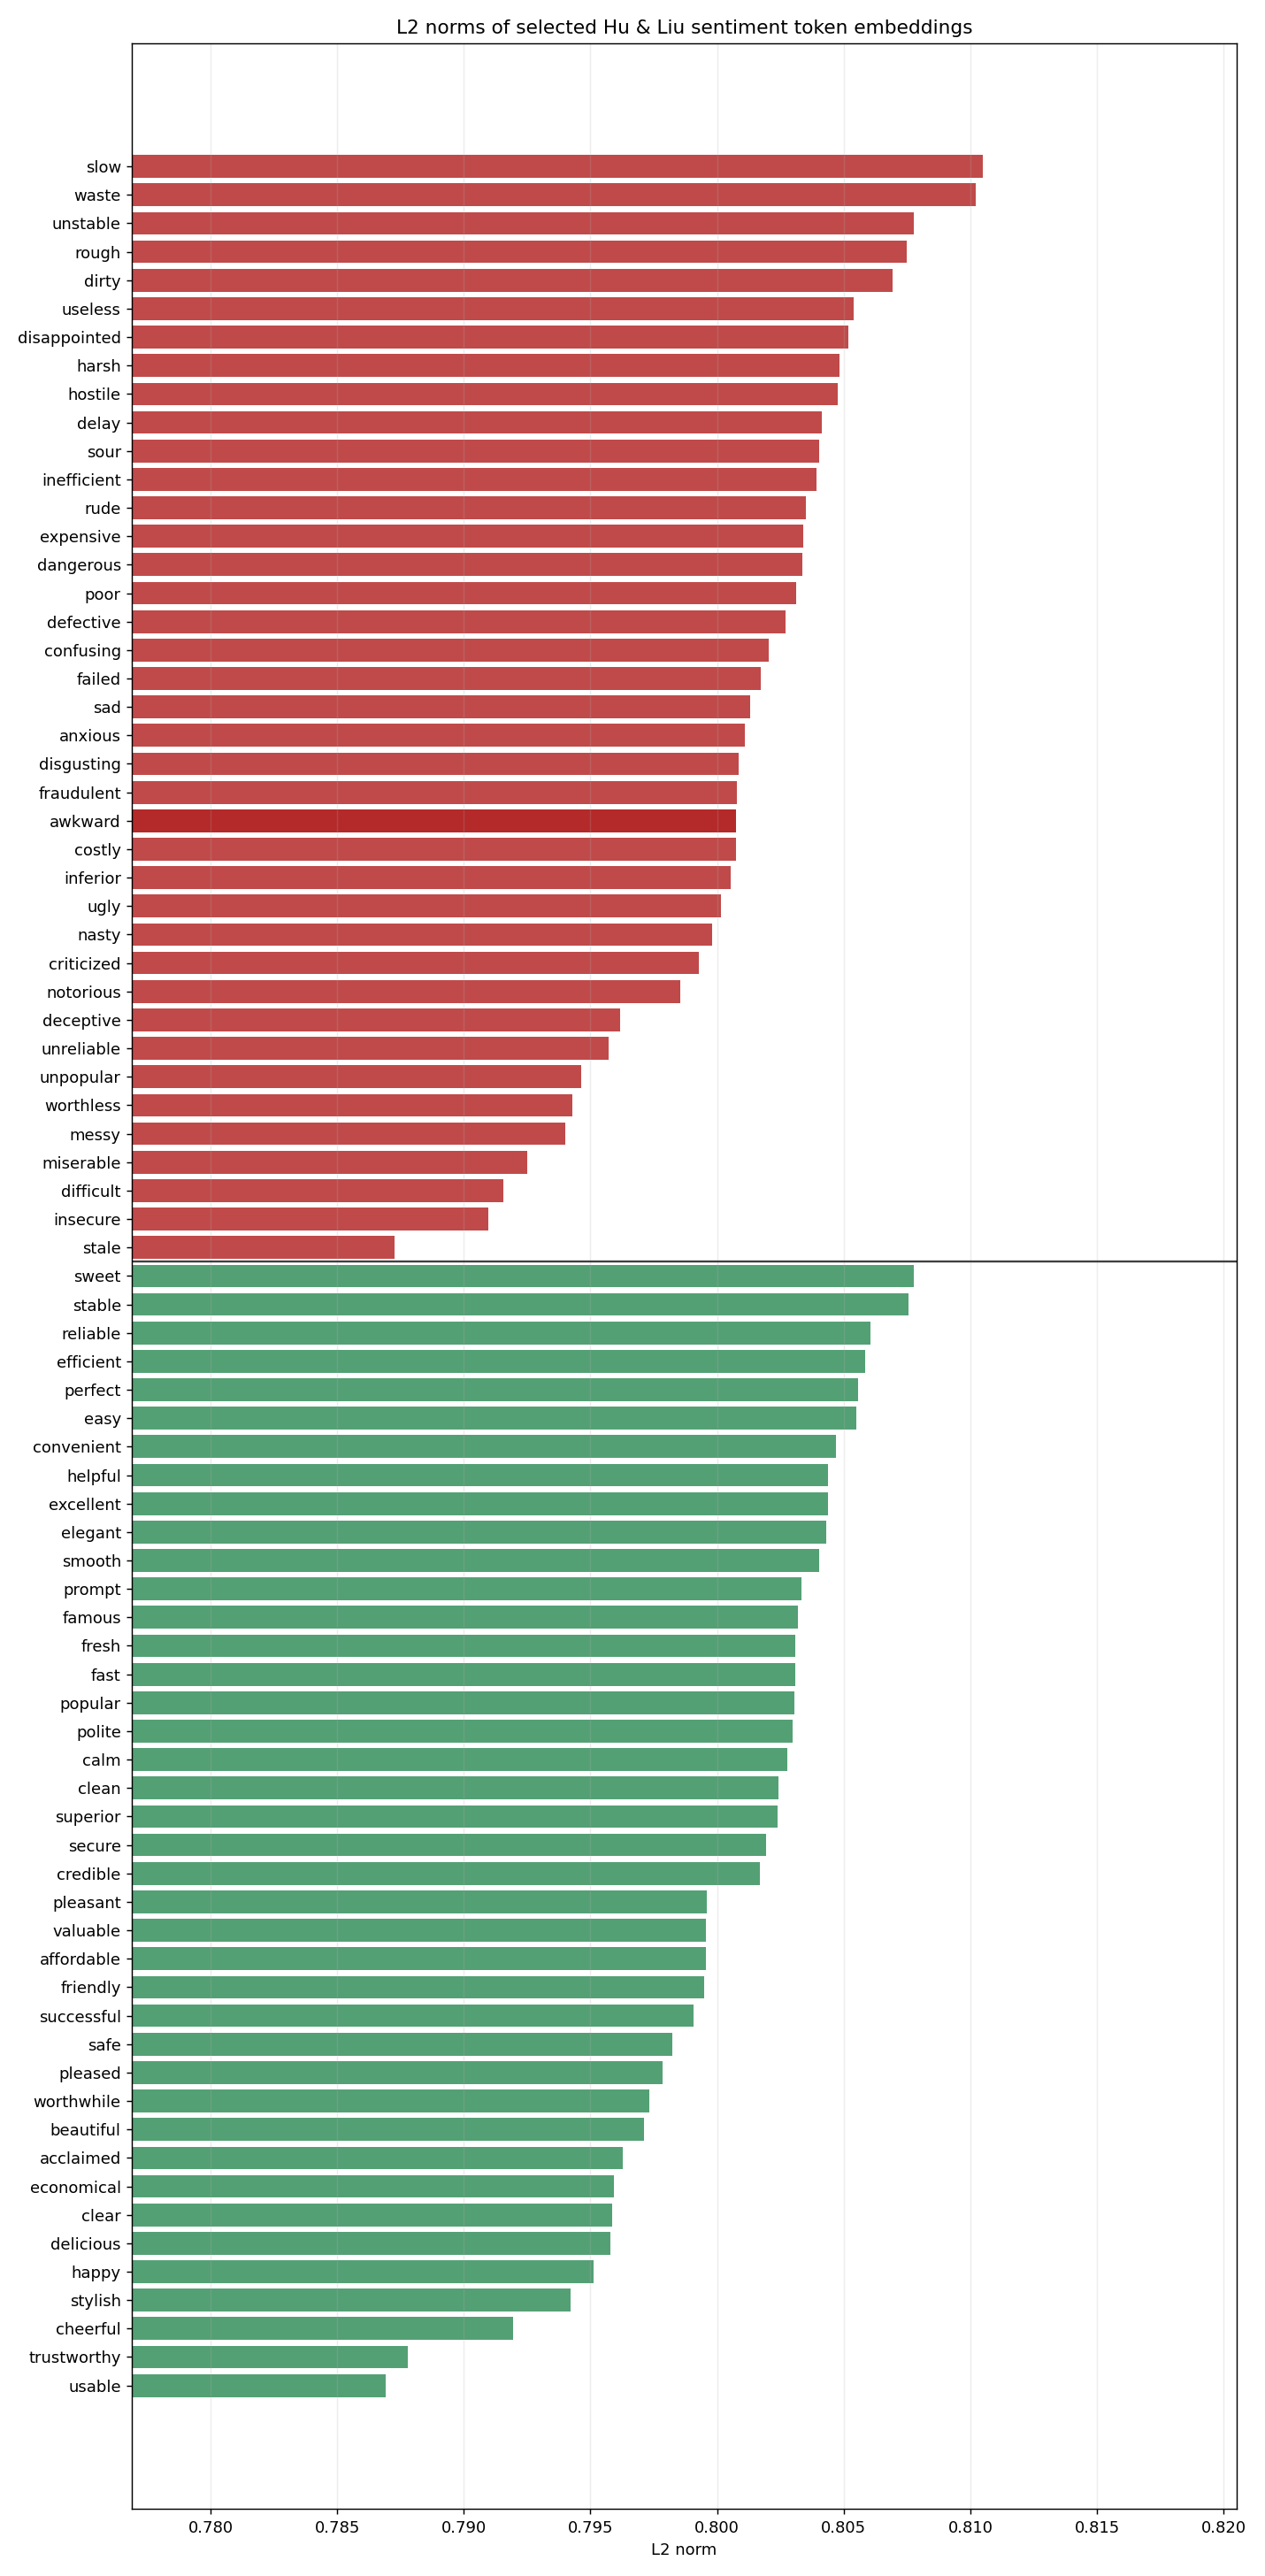

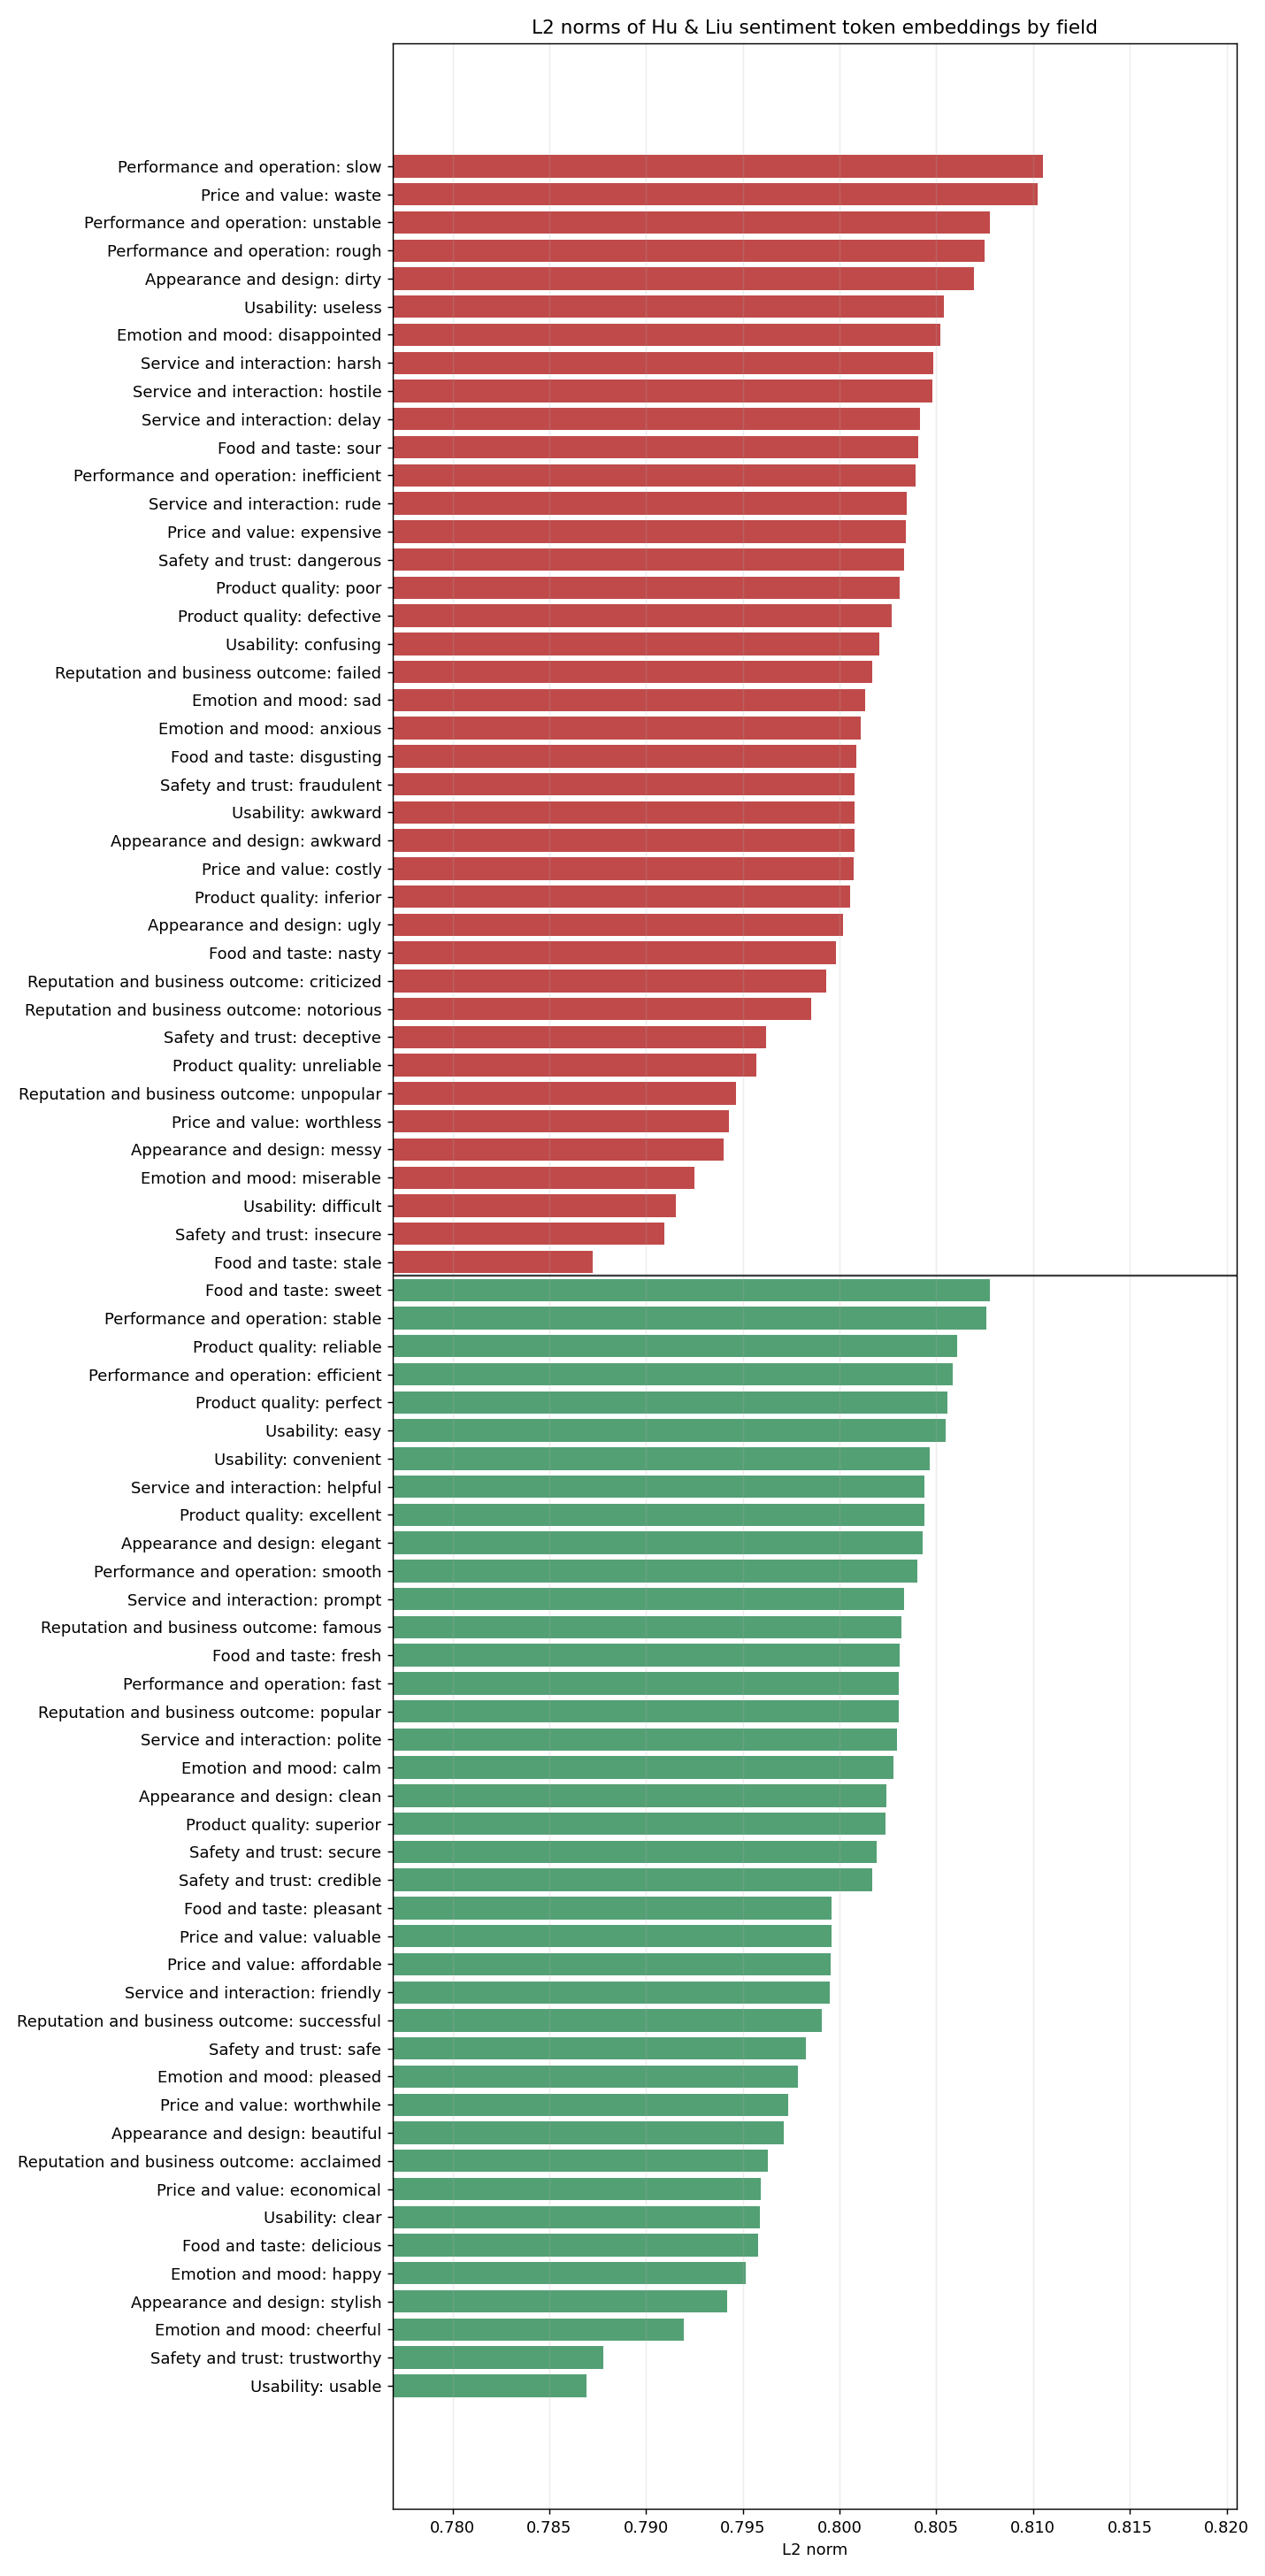

In [298]:
display_image('sentiment_embedding_norms_all_fields.png')


### Interpretation der Norm-Grafiken

Die Balken vergleichen die Embedding-Längen einzelner positiver und negativer Wörter. Jede Box fasst ein Feld zusammen.  
Wenn die Werte sehr nah beieinander liegen, bedeutet das, dass die reine Vektorlänge allein wahrscheinlich kein guter Sentiment-Indikator ist. Interessanter ist dann die Richtung der Vektoren, zum Beispiel über Cosine Similarity oder Projektion.


### 7.2 Cosine-Nachbarn

Für ausgewählte Wörter werden die ähnlichsten Token im gesamten Vokabular und zusätzlich nur innerhalb des Hu-&-Liu-Lexikons gesucht.  
So kann man vergleichen, ob die nächsten Nachbarn semantisch und sentimentbezogen sinnvoll sind.


In [ ]:
# Example words to analyze their nearest neighbors in the embedding space.
neighbor_target_words = ["good", "bad", "delicious", "disgusting"]

# Analyze the nearest neighbors of the target words in the embedding space using cosine similarity
# For each word, find the top-k nearest neighbors in general vocabulary and in the Hu Liu dictionary
sentiment_embeddings.run_cosine_neighbor_analysis(
    neighbor_target_words,
    tokenizer,
    embedding_matrix,
    positive_words,
    negative_words,
)


Cosine neighbors for 'good'
----------------------------------------------------------------------------------------
General vocabulary neighbors:
'good'               token_id= 12311 similarity=+0.7330 HuLiu:positive:good
' Good'              token_id=  7088 similarity=+0.6709 HuLiu:positive: Good
'Good'               token_id=  8620 similarity=+0.6449 HuLiu:positive:Good
' GOOD'              token_id= 29638 similarity=+0.5514 HuLiu:positive: GOOD
' excellent'         token_id=  7126 similarity=+0.4429 HuLiu:positive: excellent

Hu & Liu dictionary neighbors:
excellent            sentiment=positive token_id=  7126 similarity=+0.4429
bad                  sentiment=negative token_id=  3076 similarity=+0.3889
better               sentiment=positive token_id=  1805 similarity=+0.3700
great                sentiment=positive token_id=  1270 similarity=+0.3615
decent               sentiment=positive token_id= 12524 similarity=+0.3506

Cosine neighbors for 'bad'
-----------------------------

### Ergebnisinterpretation

Die Analyse der Cosine-Nachbarn zeigt, dass die dem Zielwort im Embedding-Raum am nächsten liegenden Token in den meisten Fällen dieselbe Sentiment-Polarität aufweisen wie das Ausgangswort. Dieses Verhalten konnte sowohl bei der Betrachtung des gesamten Modellvokabulars als auch bei der auf das Hu-&-Liu-Sentiment-Lexikon beschränkten Analyse beobachtet werden. Die Ergebnisse deuten darauf hin, dass sentimentbezogene Informationen bereits im Embedding-Raum kodiert sind und dass semantische Ähnlichkeit häufig mit einer ähnlichen Sentiment-Ausrichtung einhergeht. Positive Wörter besitzen überwiegend positive Nachbarn, während negative Wörter überwiegend von negativen Nachbarn umgeben sind. Diese Konsistenz bestätigt, dass die Embeddings nicht nur semantische Beziehungen, sondern auch sentimentbezogene Eigenschaften der Wörter erfassen.


### 7.3 Embedding-Arithmetik

In diesem Abschnitt werden einfache Rechnungen mit Embedding-Vektoren durchgeführt, zum Beispiel `good + excellent - bad`.  
Das Ergebnis ist kein echtes Token, sondern ein neuer Vektor im Embedding-Raum. Danach wird per Cosine Similarity gesucht, welche existierenden Token diesem Ergebnis am nächsten liegen.

Alle Operanden müssen genau ein Token sein. Wenn ein Wort in mehrere Tokens zerfällt, bricht die Funktion mit einer Fehlermeldung ab.


In [366]:
sentiment_embeddings.run_embedding_arithmetic_analysis(
    tokenizer,
    embedding_matrix,
    positive_words,
    negative_words,
)



Embedding arithmetic: good + excellent - bad
----------------------------------------------------------------------------------------
' excellent'         token_id=  7126 similarity=+0.7673 HuLiu:positive: excellent
' good'              token_id=  1175 similarity=+0.6207 HuLiu:positive: good
' Excellent'         token_id= 48438 similarity=+0.4961 HuLiu:positive: Excellent
'cellent'            token_id= 26128 similarity=+0.4911 
'Excellent'          token_id= 45441 similarity=+0.4538 HuLiu:positive:Excellent

Embedding arithmetic: terrible + sad - great
----------------------------------------------------------------------------------------
' sad'               token_id=  8872 similarity=+0.6892 HuLiu:negative: sad
' terrible'          token_id= 11527 similarity=+0.5581 HuLiu:negative: terrible
'Sad'                token_id= 41052 similarity=+0.3597 HuLiu:negative:Sad
' horrible'          token_id= 19201 similarity=+0.3532 HuLiu:negative: horrible
' Sad'               token_id= 21995 s

### Ergebnisinterpretation

Bei der Embedding-Arithmetik werden nicht Token-IDs addiert, sondern Embedding-Vektoren.  
Das Ergebnis ist ein künstlicher Vektor. Die ausgegebenen Tokens sind diejenigen existierenden Vocabulary-Embeddings, die diesem Ergebnisvektor per Cosine Similarity am nächsten liegen. Niedrige maximale Similarity-Werte bedeuten, dass der Ergebnisvektor keinem echten Token sehr nahe kommt.


### 7.4 Sentiment-Richtung

Hier wird eine Sentiment-Richtung mit `embedding("good") - embedding("bad")` gebildet.  
Die Wörter aus den Feldpaaren werden auf diese Richtung projiziert, um zu prüfen, ob positive Wörter tendenziell anders liegen als negative Wörter.


In [367]:
sentiment_embeddings.run_sentiment_direction_projection(tokenizer, embedding_matrix)



Projection onto sentiment direction: embedding('good') - embedding('bad')
good token_id=1175, bad token_id=3076
------------------------------------------------------------------------------------------------
excellent        sentiment=positive field=product_quality    token_id= 7126 projection=+0.1959
delicious        sentiment=positive field=food_taste         token_id=17319 projection=+0.0676
elegant          sentiment=positive field=appearance_design  token_id=20654 projection=+0.0588
superior         sentiment=positive field=product_quality    token_id= 8936 projection=+0.0534
beautiful        sentiment=positive field=appearance_design  token_id= 5389 projection=+0.0528
reliable         sentiment=positive field=product_quality    token_id= 9630 projection=+0.0523
sweet            sentiment=positive field=food_taste         token_id= 7353 projection=+0.0515
perfect          sentiment=positive field=product_quality    token_id= 3962 projection=+0.0379
pleasant         sentiment=pos

### Ergebnisinterpretation

Die Sentiment-Richtung wird als `embedding("good") - embedding("bad")` definiert.  
Positive Projektionswerte bedeuten, dass ein Wort stärker in Richtung `good` liegt; negative Werte liegen stärker in Richtung `bad`. Entscheidend ist nicht jeder einzelne Punkt, sondern ob positive und negative Wörter innerhalb der Felder tendenziell unterschiedlich verteilt sind.


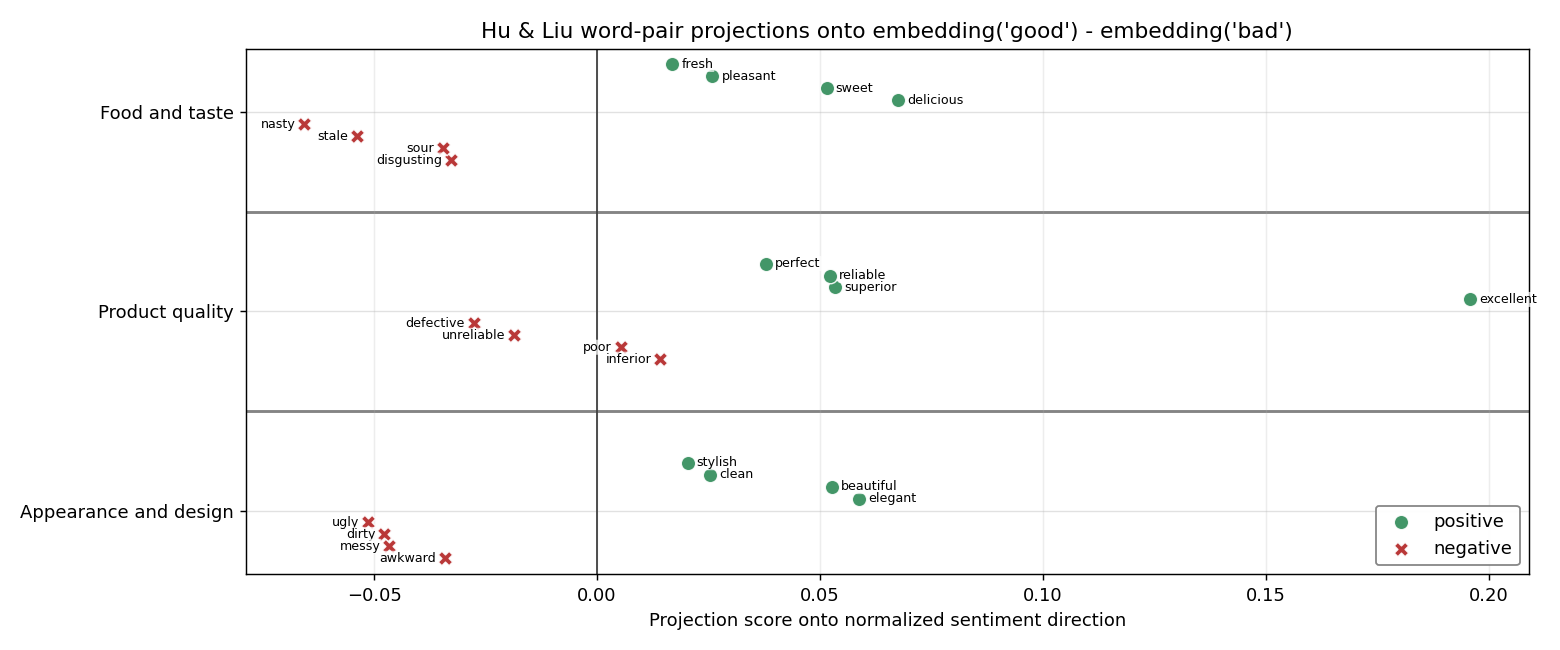

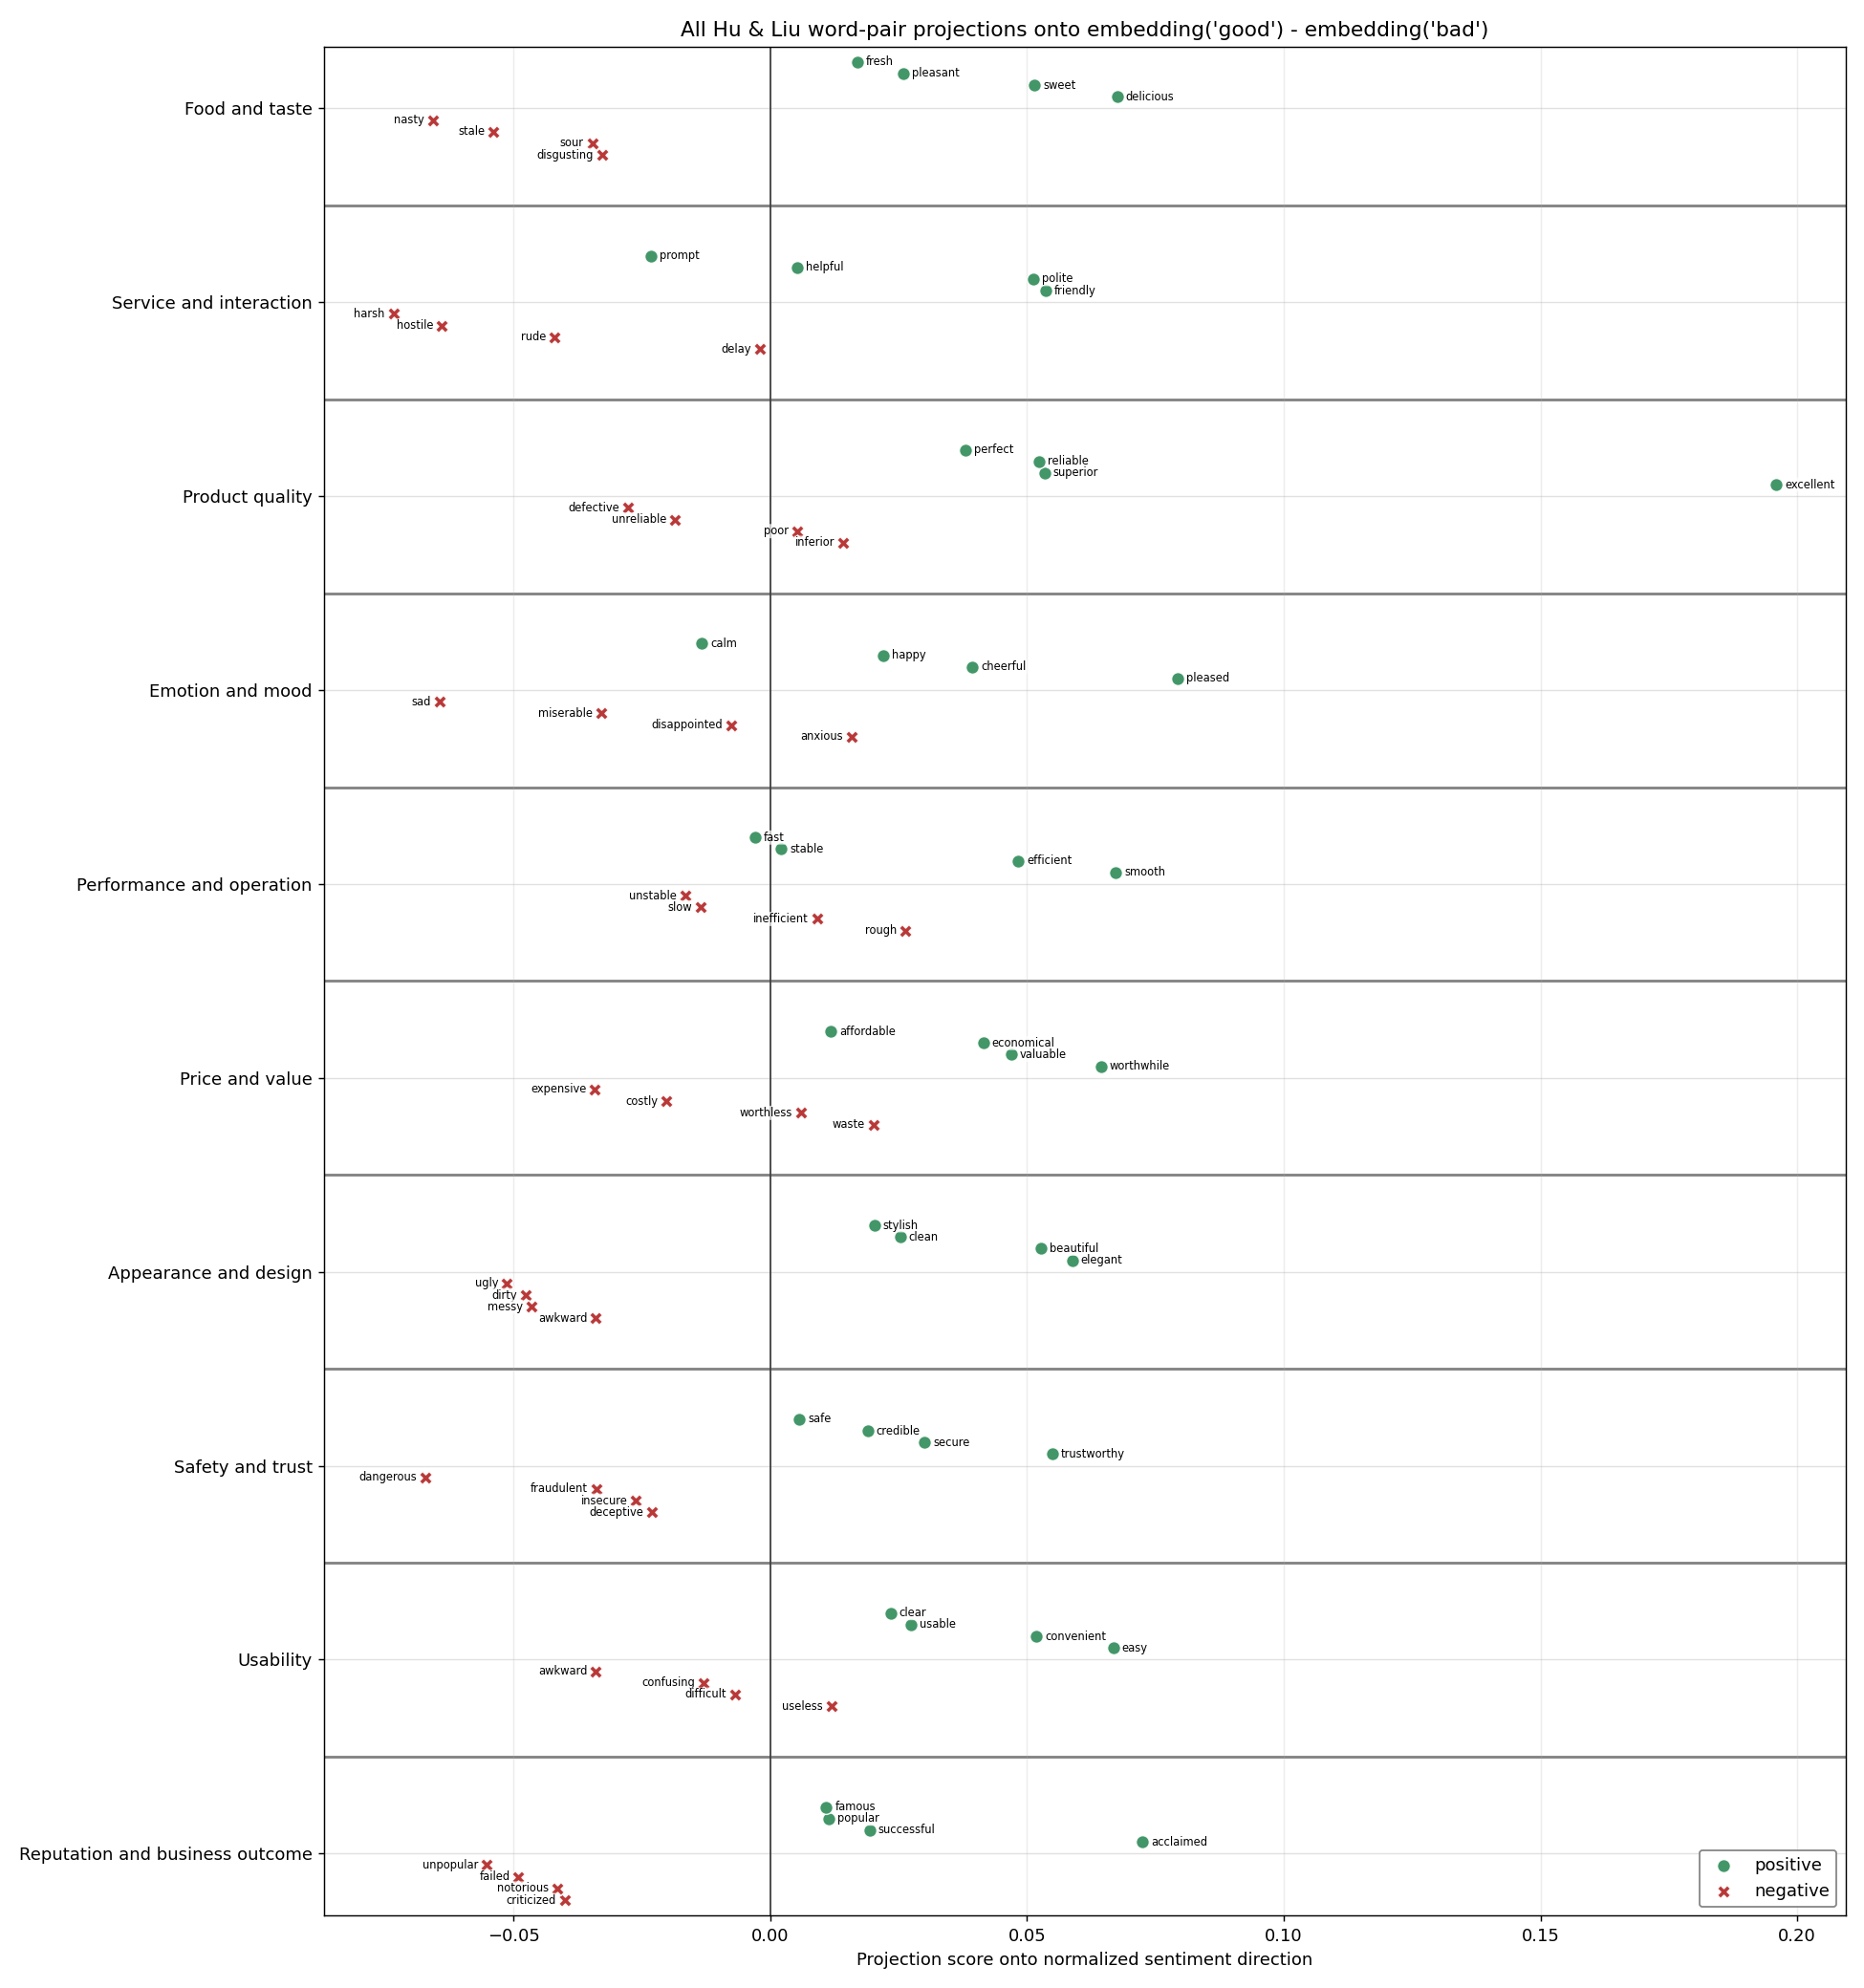

In [368]:
display_image('sentiment_direction_projection_by_field.png')
display_image('sentiment_direction_projection_all_fields.png')


### Interpretation der Projektionsgrafiken

Jede Zeile entspricht einem Feld, zum Beispiel Food oder Product Quality.  
Die horizontale Position zeigt den Projektionswert auf die Sentiment-Richtung. Unterschiedliche Marker und Farben trennen positive und negative Hu-&-Liu-Wörter. Die Trennlinien helfen, die Felder visuell auseinanderzuhalten.


## 8. Logistische Regression als Linear Probe

Die logistische Regression wird als lineare Sonde verwendet.  
Sie prüft, ob positive und negative Hu-&-Liu-Wörter im Input-Embedding-Raum durch eine lineare Entscheidungsgrenze trennbar sind.

Es werden nur Hu-&-Liu-Wörter verwendet, die aus genau einem Token bestehen. Der Split ist stratifiziert, sodass Train- und Testdaten denselben positiven/negativen Anteil behalten.


In [369]:
classifier, scaler = run_logistic_regression_probe(sentiment_state)



  Kapitel 8: Logistic Regression Sentiment Linear Probe

Loaded fixed logistic-regression split from D:\Master\Projects\AI_Frameworks_Ex\assignement\output\json\hu_liu_logistic_regression_split.json

X.shape = (2254, 1024)
y.shape = (2254,)
Positive labels: 865
Negative labels: 1389
Train examples: 1803
Test examples : 451
Train labels  : positive=692, negative=1111
Test labels   : positive=173, negative=278

--- Logistic Regression Linear Probe Evaluation: test set ---
Accuracy : 0.9690
Precision: 0.9760
Recall   : 0.9422
F1 score : 0.9588

Confusion matrix:
[[274   4]
 [ 10 163]]

Classification report:
              precision    recall  f1-score   support

    negative       0.96      0.99      0.98       278
    positive       0.98      0.94      0.96       173

    accuracy                           0.97       451
   macro avg       0.97      0.96      0.97       451
weighted avg       0.97      0.97      0.97       451


Misclassified test words:
--------------------------------

### Ergebnisinterpretation

Die logistische Regression ist hier ein Linear Probe. Sie prüft, ob positive und negative Wörter im ursprünglichen Embedding-Raum linear trennbar sind.  
Die Test-Metriken sind wichtiger als die Train-Metriken, weil sie zeigen, ob die gefundene Trennung auf ungesehenen Wörtern funktioniert. Falsch klassifizierte Wörter helfen zu verstehen, wo das Modell oder das Lexikon mehrdeutig ist.


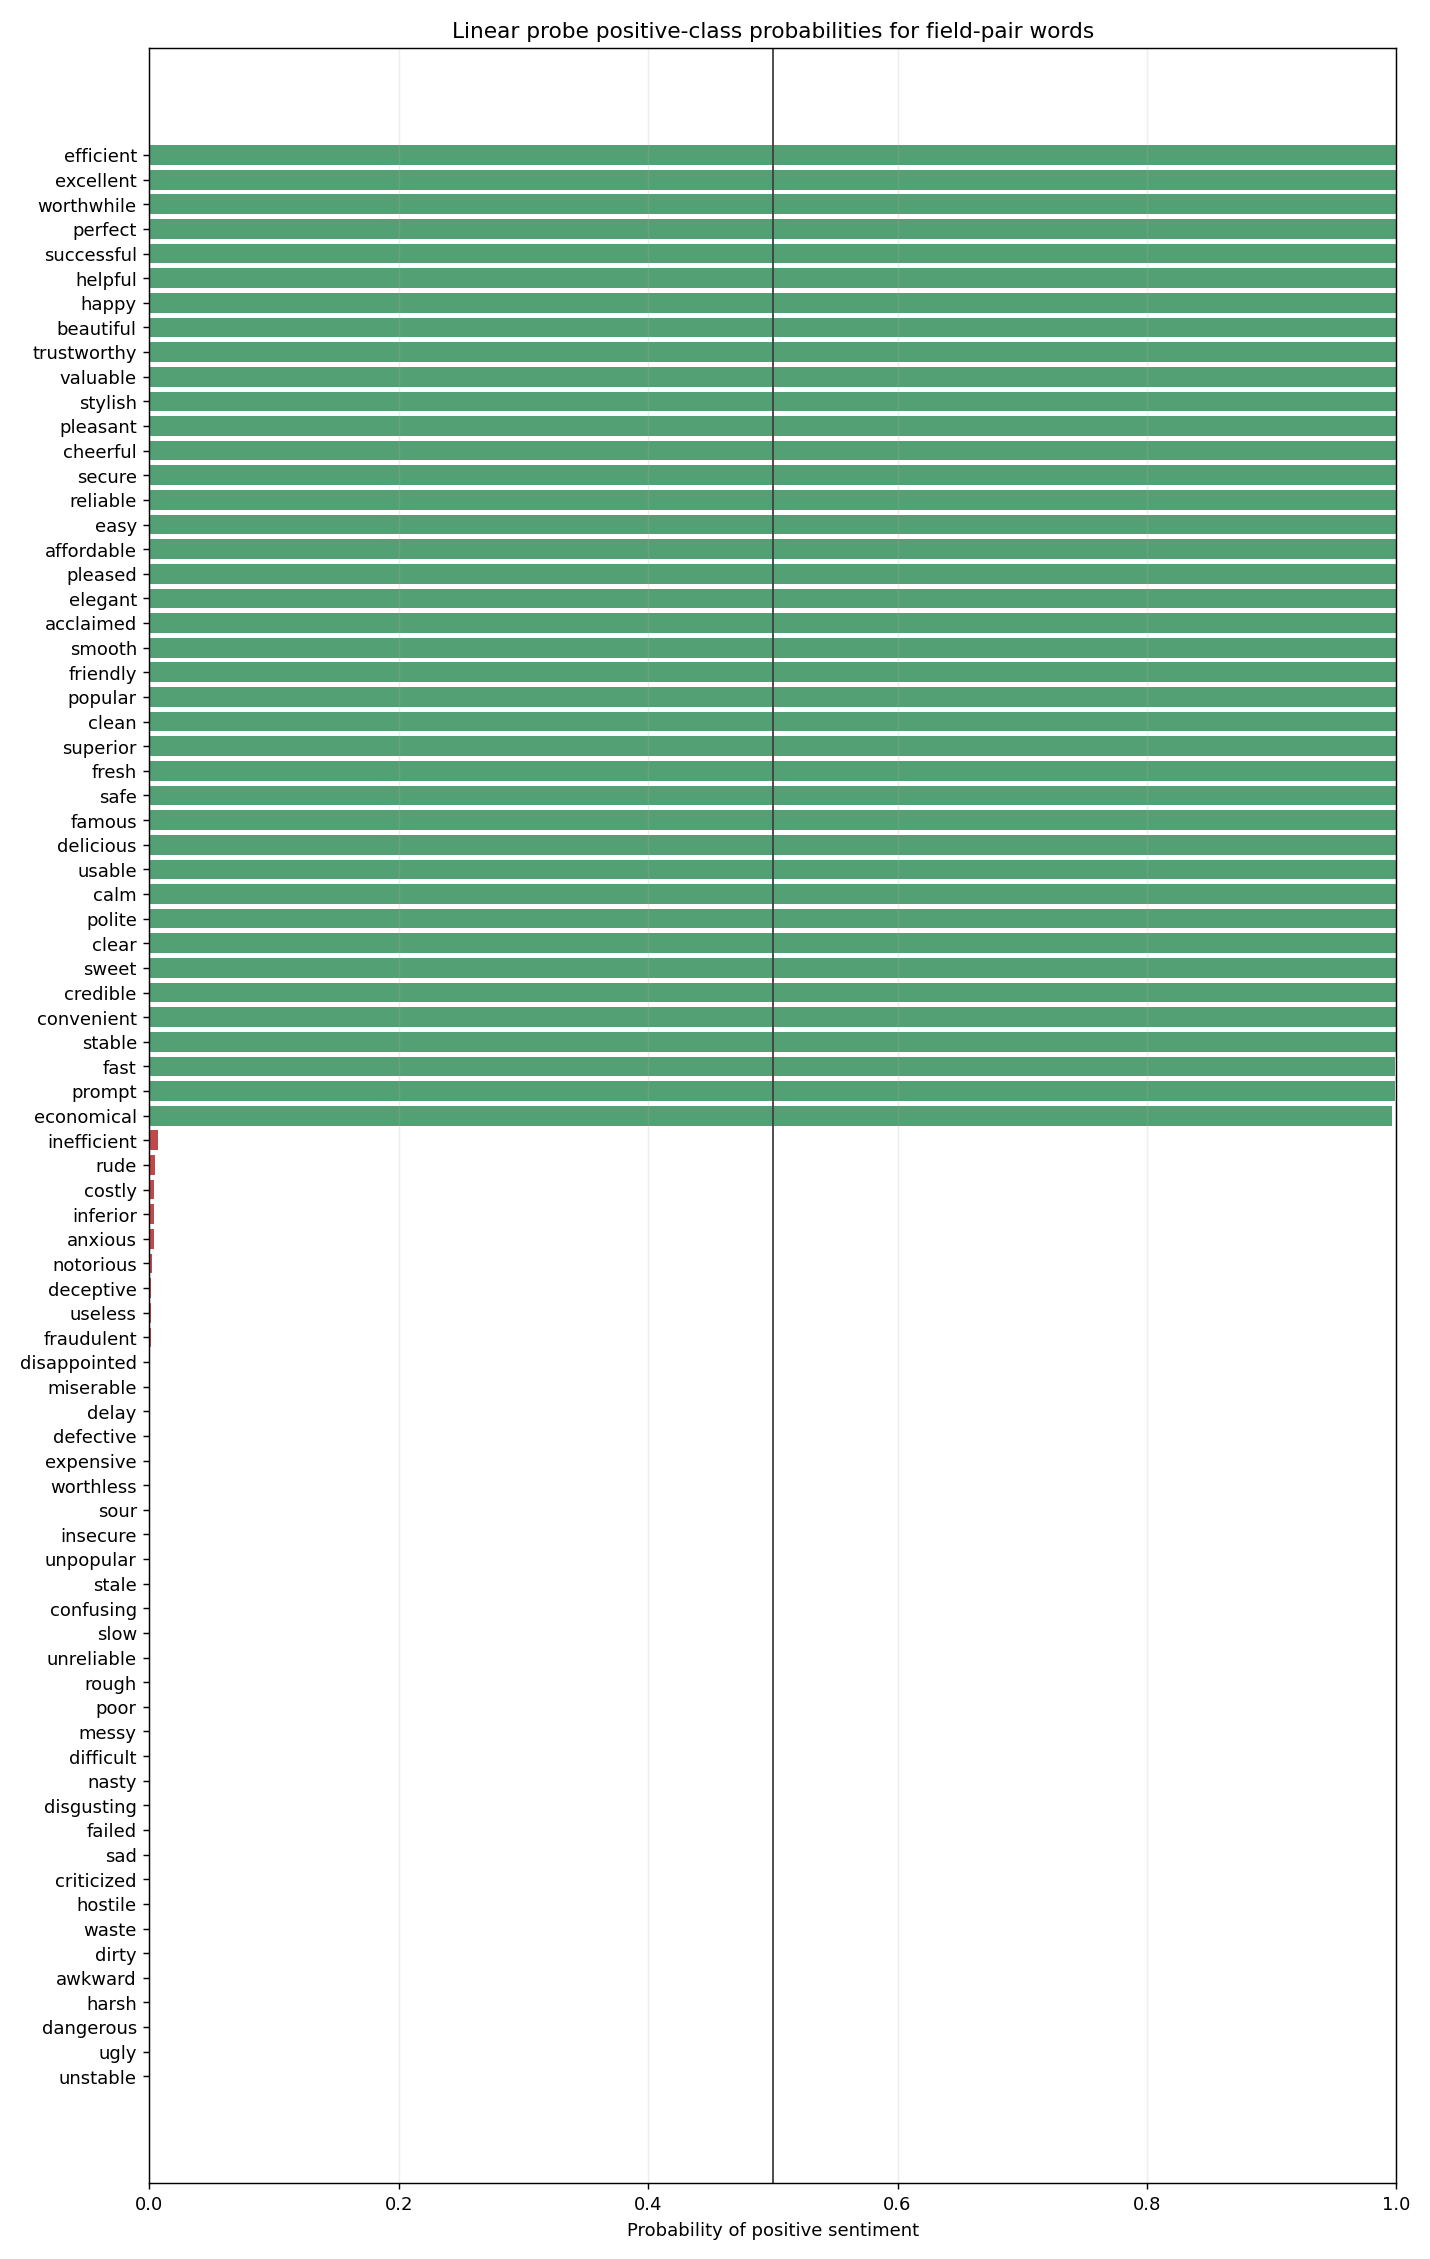

In [370]:
display_image('logistic_regression_field_word_probabilities.png')


### Interpretation der Klassifikator-Grafik

Die Balken zeigen die vom Linear Probe geschätzte Wahrscheinlichkeit für positives Sentiment.  
Werte nahe `0` werden als stark negativ interpretiert, Werte nahe `1` als stark positiv. Die vertikale Linie bei `0.5` ist die Entscheidungsgrenze des Klassifikators.


## 9. Stanford Sentiment Treebank SST-2

SST-2 ist ein Satz-Level-Datensatz für binäre Sentiment-Analyse.  
Dieses Kapitel lädt den Datensatz, zeigt Splits, Features, Beispielzeilen und Label-Verteilungen.

Für das Projekt ist SST-2 spannend, weil man damit Wort-Level-Sentiment aus Hu & Liu mit Satz-Level-Sentiment vergleichen kann.


In [371]:
run_sst2_inspection()



  Kapitel 9: Stanford Sentiment Treebank SST-2

SST-2 is a sentence-level sentiment dataset. Each example contains a sentence and a binary label: 0 = negative, 1 = positive.

Loaded SST-2 from Hugging Face dataset: nyu-mll/glue

SST-2 splits:
- train      examples=67349
- validation examples=872
- test       examples=1821

SST-2 features:
{'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive']), 'idx': Value('int32')}

Example rows from the training split:
label=0 (negative) idx=0      sentence=hide new secretions from the parental units 
label=0 (negative) idx=1      sentence=contains no wit , only labored gags 
label=1 (positive) idx=2      sentence=that loves its characters and communicates something rather beautiful about human nature 
label=0 (negative) idx=3      sentence=remains utterly satisfied to remain the same throughout 
label=0 (negative) idx=4      sentence=on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
label=0 (negati

### Ergebnisinterpretation

SST-2 enthält vollständige Sätze statt einzelner Wörter.  
Damit eignet sich der Datensatz für einen späteren Vergleich: Hu & Liu prüft Sentiment auf Wortebene, SST-2 prüft Sentiment im Kontext ganzer Sätze. Besonders interessant wären Fälle mit Negation oder gemischtem Sentiment.


## 10. Zusammenfassung

Das Notebook trennt jetzt klar zwischen Ausführung und Implementierung:

- `main.py` ruft nur die Kapitel-Funktionen auf.
- Die Analysefunktionen liegen in separaten Python-Dateien.
- Die ersten sieben Kapitel bleiben erhalten.
- Danach folgen die lineare Sentiment-Sonde und die SST-2-Datensatzinspektion.
